In [1]:
%reload_ext autoreload
%autoreload 2

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import holodeck as holo
from holodeck import utils, plot, host_relations, galaxy_profiles
from holodeck.constants import MSOL, PC, GYR

# Load log and set logging level
log = holo.log
log.setLevel(log.WARNING)

# Mbh - Mbulge Relations

11:31:30 WARNING : The `mamp` parameter has been deprecated!  Use `mamp_log10`! [host_relations.py:__init__]


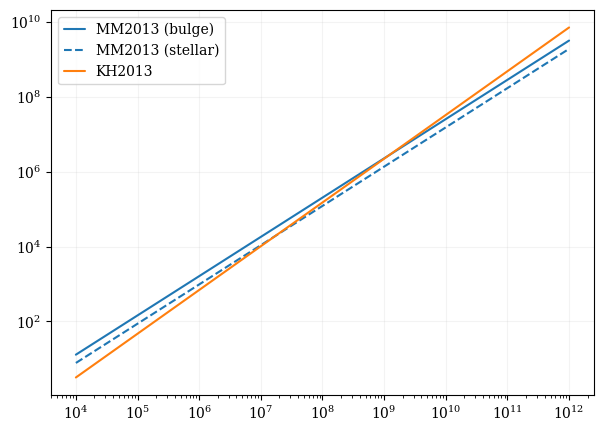

In [2]:
mbulge = np.logspace(4, 12, 100)
generic = host_relations.MMBulge_Standard(mamp=1e8*MSOL, mplaw=1.0)
MM2013 = host_relations.MMBulge_MM2013()
KH2013 = host_relations.MMBulge_KH2013()

fig, ax = plot.figax()

xx = mbulge
yy = MM2013.mbh_from_mbulge(mbulge*MSOL, scatter=False)/MSOL
hh, = ax.plot(xx, yy, label='MM2013 (bulge)')

yy = MM2013.mbh_from_mstar(mbulge*MSOL, scatter=False)/MSOL
ax.plot(xx, yy, label='MM2013 (stellar)', color=hh.get_color(), ls='--')

yy = KH2013.mbh_from_mbulge(mbulge*MSOL, scatter=False)/MSOL
ax.plot(xx, yy, label='KH2013')

plt.legend()
plt.show()

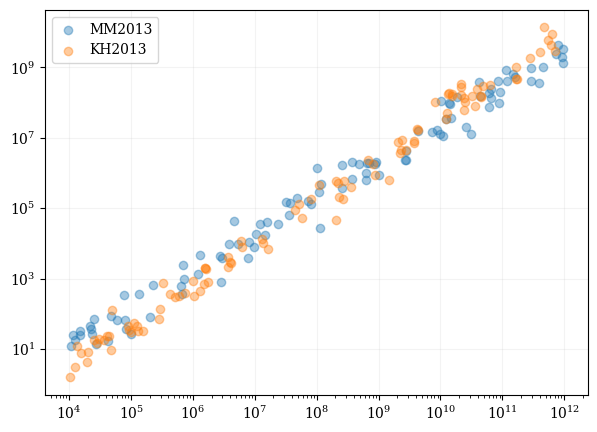

In [3]:
MM2013 = host_relations.MMBulge_MM2013()
KH2013 = host_relations.MMBulge_KH2013()

fig, ax = plot.figax()

NUM = 1e2

xx = 10.0**np.random.uniform(*np.log10([mbulge.min(), mbulge.max()]), int(NUM))
yy = MM2013.mbh_from_mbulge(xx*MSOL, scatter=True)/MSOL
ax.scatter(xx, yy, label='MM2013', alpha=0.4)

xx = 10.0**np.random.uniform(*np.log10([mbulge.min(), mbulge.max()]), int(NUM))
yy = KH2013.mbh_from_mbulge(xx*MSOL, scatter=True)/MSOL
ax.scatter(xx, yy, label='KH2013', alpha=0.4)

plt.legend()
plt.show()

# Stellar-Mass vs. Halo-Mass Relation

In [4]:
mhalo = np.logspace(10, 15, 100)

## Guo et al. 2010

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

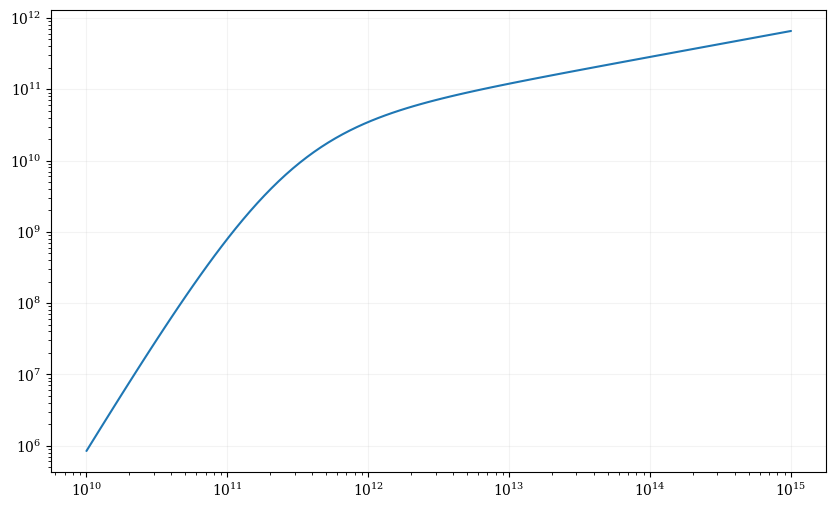

In [5]:
guo = host_relations.Guo_2010()
mstar = guo.stellar_mass(mhalo * MSOL) / MSOL

fig, ax = plt.subplots(figsize=[10, 6])
ax.set(xscale='log', yscale='log')
ax.grid(True)

ax.plot(mhalo, mstar)

plt.plot

<b>plot from the paper:</b>
<div>
<img src="attachment:Screen%20Shot%202021-08-19%20at%2012.16.41%20PM.png" width="50%"/>
</div>

## Behroozi et al. 2013

In [6]:
rooz = host_relations.Behroozi_2013()

C:\Users\pxt561\holodeck\holodeck\host_relations.py:1496: RuntimeWarning: overflow encountered in exp
  t3 = 1 + np.exp(10.0 ** -xx)


This doesn't match the paper plot well (Behroozi+2013, Fig.7, left-panel)
but I think that's because what they plot is the mean, marginalized over parameter uncertainties,
while this plot is using the mean values of each parameter.  Those aren't the same thing!

[0.1, 1, 2, 3, 4, 5, 6, 7, 8]


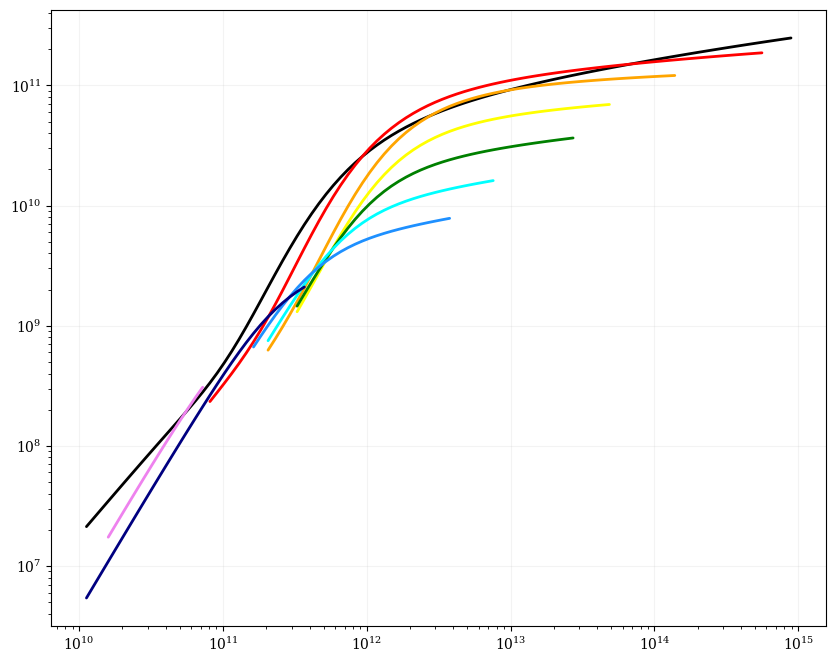

In [7]:
NOTE = """This doesn't match the paper plot well (Behroozi+2013, Fig.7, left-panel)
but I think that's because what they plot is the mean, marginalized over parameter uncertainties,
while this plot is using the mean values of each parameter.  Those aren't the same thing!
"""
print(NOTE)

zlist = [0.1,] + np.arange(1, 9).tolist()
colors = ['k', 'r', 'orange', 'yellow', 'green', 'cyan', 'dodgerblue', 'navy', 'violet']
print(zlist)
limits = [
    [1e10, 1e15],   # k
    [8e10, 6e14],   # r
    [2e11, 1.5e14], # ora
    [3e11, 5e13],   # yel
    [3e11, 3e13],   # grn
    [2e11, 8e12],   # cyan
    [1.5e11, 4e12], # light blue
    [1e10, 4e11],   # dark blue
    [1.5e10, 8e10]  # violet
]


fig, ax = plt.subplots(figsize=[10, 8])
ax.set(xscale='log', yscale='log')
ax.grid(True)

for zz, cc, lim in zip(zlist, colors, limits):
    mstar = rooz.stellar_mass(mhalo * MSOL, zz) / MSOL
    idx = (lim[0] < mhalo) & (mhalo < lim[1])
    # idx = slice(None)
    yy = mstar
    # yy = mstar / mhalo
    ax.plot(mhalo[idx], yy[idx], color=cc, lw=2.0)

plt.show()


<b>plot from the paper (Behroozi+2013, Fig.7):</b>
<div>
<img src="attachment:Screen%20Shot%202021-08-19%20at%2012.21.39%20PM.png" width="100%"/>
</div>

In [8]:
redz = np.linspace(0.0, 6.0, 40)

mstar = rooz.stellar_mass(mhalo[:, np.newaxis] * MSOL, redz[np.newaxis, :]) / MSOL

### Test/Check interpolation from mstar ==> mhalo

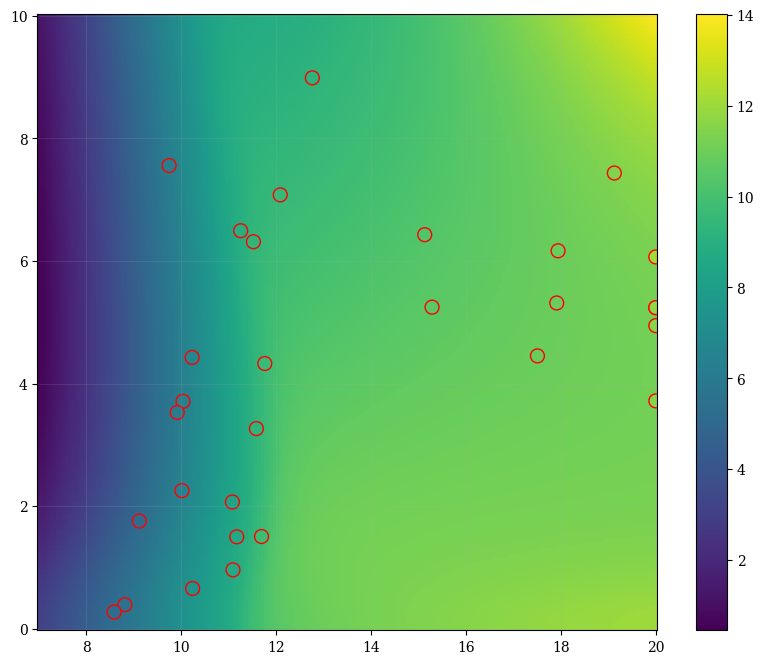

In [9]:
rooz = host_relations.Behroozi_2013()

# breaker()

mhalo = rooz._mhalo_grid
redz = rooz._redz_grid
mstar = rooz._mstar

NUM = 30

fig, ax = plt.subplots(figsize=[10, 8])
pcm = ax.pcolormesh(np.log10(mhalo/MSOL), redz, np.log10(mstar/MSOL).T)
cbar = plt.colorbar(pcm, ax=ax)

ss = MSOL * 10.0 ** np.random.uniform(5, 13, NUM)
zz = np.random.uniform(0.0, 9.0, NUM)

hh = rooz.halo_mass(ss, zz)

ss = np.log10(ss/MSOL)
hh = np.log10(hh/MSOL)
cc = cbar.cmap(cbar.norm(ss))

ax.scatter(hh, zz, c=cc, edgecolor='r', lw=1.0, s=100)


plt.show()

7.00e+00, 7.62e+00, 9.03e+00, 1.35e+01, 1.80e+01, 1.94e+01, 2.00e+01 (40400,)
hh=2.0000e+01


C:\Users\pxt561\AppData\Local\Temp\ipykernel_17352\1741794414.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(mm, zz, c=smap.to_rgba(hh), edgecolor='r', lw=2.0)


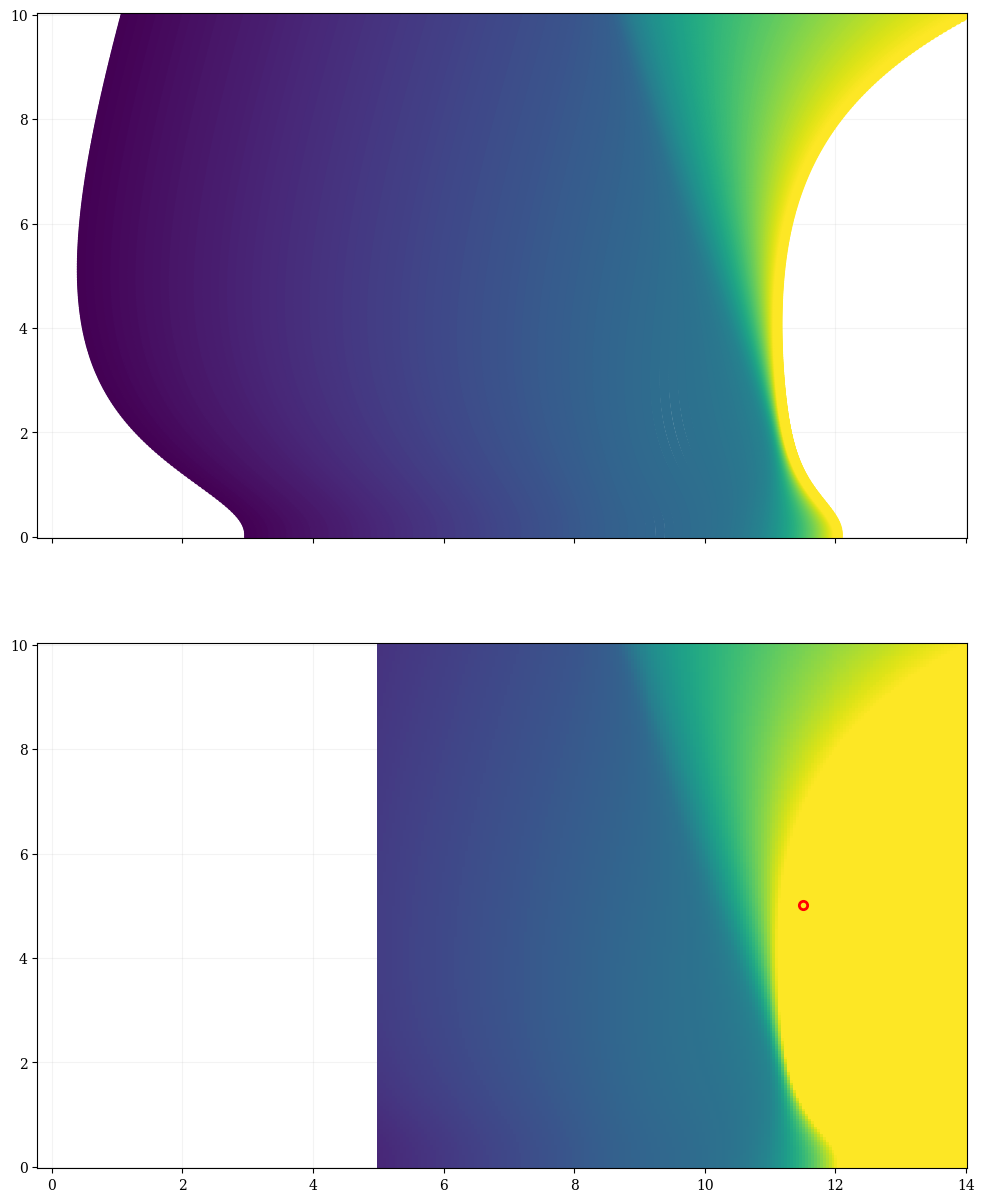

In [10]:
fig, axes = plot.figax(figsize=[12, 15], scale='lin', nrows=2, sharex=True, sharey=True)

aa = rooz._aa
bb = rooz._bb
cc = rooz._cc
print(utils.stats(cc), cc.shape)

norm = mpl.colors.Normalize(cc.min(), cc.max())
smap = mpl.cm.ScalarMappable(norm, cmap='viridis')
colors = smap.to_rgba(cc)
ax = axes[0]
ax.scatter(aa, bb, c=colors)


ax = axes[1]
xx = np.log10(rooz._mstar_grid/MSOL)
yy = rooz._redz_grid
ax.pcolormesh(xx, yy, rooz._grid.T, norm=smap.norm, cmap=smap.cmap)

zz = [5.01]
mm = [11.5]
hh = rooz._mhalo_from_mstar_redz(np.atleast_2d([mm, zz]).T)[0]
print(f"hh={hh:.4e}")
ax.scatter(mm, zz, c=smap.to_rgba(hh), edgecolor='r', lw=2.0)

plt.show()

## Check reversing relation for consistency

In [11]:
NUM = 1000
behr = host_relations.Behroozi_2013()

# mbh = np.random.uniform(5, 11, NUM)
# mbh = np.linspace(5, 11, NUM)
mbh = np.linspace(5, 10, NUM)
mbh = MSOL * (10.0 ** mbh)
# redz = np.random.uniform(0.0, 6.0, NUM)
redz = np.zeros_like(mbh)

mmb = host_relations.get_mmbulge_relation()
mstar = mmb.mstar_from_mbh(mbh, scatter=False)
print(f"{mstar.max()/MSOL=:.4e}")

mhalo = behr.halo_mass(mstar, redz)
print(f"{mhalo.max()/MSOL=:.4e}")

mstar_check = behr.stellar_mass(mhalo, redz)
mhalo_check = behr.halo_mass(mstar, redz)
print(f"{mstar_check.max()/MSOL=:.4e}")
print(f"{mhalo_check.max()/MSOL=:.4e}")

print(f"mstar  input: {holo.utils.stats(mstar/MSOL)}")
print(f"mstar output: {holo.utils.stats(mstar_check/MSOL)}")
# bads = ~np.isclose(mstar, mstar_check, rtol=0.1)
# if np.any(bads):
#     print(f"bad mstar input  : {mstar[bads]/MSOL}")
#     print(f"bad mstar output : {mstar_check[bads]/MSOL}")
# assert not np.any(bads)

print(f"mhalo  input: {holo.utils.stats(mhalo/MSOL)}")
print(f"mhalo output: {holo.utils.stats(mhalo_check/MSOL)}")
# bads = ~np.isclose(mhalo, mhalo_check, rtol=0.1)
# if np.any(bads):
#     print(f"bad mhalo input  : {mhalo[bads]/MSOL}")
#     print(f"bad mhalo output : {mhalo_check[bads]/MSOL}")
# assert not np.any(bads)

mstar.max()/MSOL=2.1418e+12
mhalo.max()/MSOL=1.0000e+20
mstar_check.max()/MSOL=1.0995e+12
mhalo_check.max()/MSOL=1.0000e+20
mstar  input: 1.14e+08, 1.86e+08, 5.42e+08, 1.56e+10, 4.51e+11, 1.32e+12, 2.14e+12
mstar output: 1.14e+08, 1.86e+08, 5.41e+08, 1.57e+10, 4.51e+11, 1.10e+12, 1.10e+12
mhalo  input: 3.83e+10, 5.48e+10, 1.08e+11, 6.23e+11, 4.54e+16, 1.00e+20, 1.00e+20
mhalo output: 3.83e+10, 5.48e+10, 1.08e+11, 6.23e+11, 4.54e+16, 1.00e+20, 1.00e+20


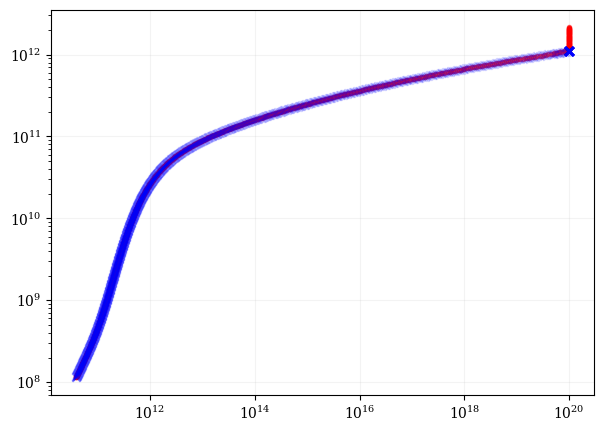

In [12]:
fig, ax = plot.figax()
ax.scatter(mhalo/MSOL, mstar/MSOL, color='r', marker='.', alpha=0.5)
ax.scatter(mhalo/MSOL, mstar_check/MSOL, color='b', marker='x', alpha=0.2)

plt.show()

# Density Profiles

## NFW

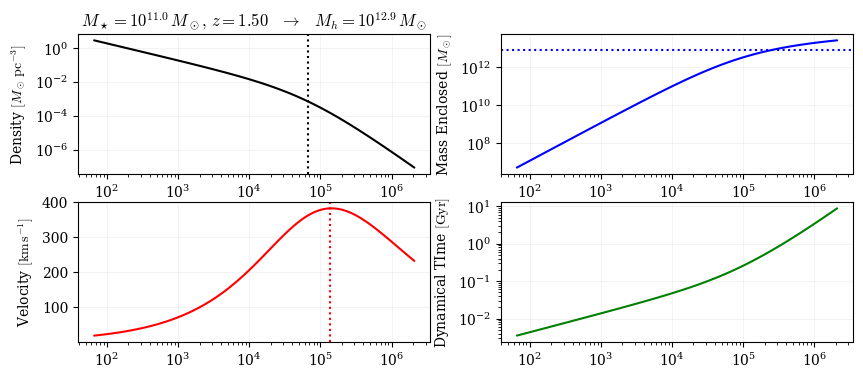

In [13]:
mstar = 1e11 * MSOL
zz = 1.5

DENS_UNITS = MSOL / PC ** 3

nfw = galaxy_profiles.NFW
smhm = host_relations.Behroozi_2013()
mhalo = smhm.halo_mass(mstar, zz)

fig, axes = plot.figax(figsize=[10, 4], ncols=2, nrows=2)
axes = axes.flatten()

# ---- Density
ax_dens = axes[0]
mstar_str = f"10^{{{np.log10(mstar/MSOL):.1f}}} \, M_\odot"
mhalo_str = f"10^{{{np.log10(mhalo/MSOL):.1f}}} \, M_\odot"
ax_dens.set_title(fr"$M_\star = {mstar_str}, \, z = {zz:.2f} \;\;\; \rightarrow \;\;\; M_h = {mhalo_str}$")

ax_dens.set(xlabel='Radius $[\mathrm{pc}]$', ylabel='Density $[M_\odot \mathrm{\, pc}^{-3}]$')
ax_dens.grid(True)

rscale = nfw.radius_scale(mhalo, zz)

rads = np.logspace(-3, 1.5, 100) * rscale
dens = nfw.density(rads, mhalo, zz)

hh, = ax_dens.plot(rads/PC, dens/DENS_UNITS, color='k')
ax_dens.axvline(rscale/PC, color='k', ls=':')


# ---- Mass
col = 'b'
# ax_mass = ax_dens.twinx()
ax_mass = axes[1]
ax_mass.set(yscale='log', ylabel='Mass Enclosed $[M_\odot]$')
# plot.set_axis_color(ax_mass, color=col, side='right')

mass = nfw.mass(rads, mhalo, zz)
ax_mass.plot(rads/PC, mass/MSOL, ls='-', color=col)
ax_mass.axhline(mhalo/MSOL, ls=':', color=col)


# ---- Velocity
col = 'r'
# ax_velo = ax_dens.twinx()
ax_velo = axes[2]
VELS_UNITS = 1e5
ax_velo.set(yscale='linear', ylabel='Velocity $[\mathrm{km \, s}^{-1}]$')
# plot.set_axis_color(ax_velo, color=col, side='right')
# plot.set_axis_pos(ax_velo, 'y', pos=1.1, side='right')

velo = nfw.velocity_circular(rads, mhalo, zz)
ax_velo.plot(rads/PC, velo/VELS_UNITS, color=col, ls='-')
idx = np.argmax(velo)
vmax_rad = rads[idx]
ax_velo.axvline(vmax_rad/PC, ls=':', color=col)

# ---- Dynamical Time
col = 'g'
# ax_time = ax_dens.twinx()
ax_time = axes[3]
TIME_UNITS = GYR
ax_time.set(yscale='log', ylabel='Dynamical TIme $[\mathrm{Gyr}]$')
# plot.set_axis_color(ax, color=col, side='right')
# plot.set_axis_pos(ax, 'y', pos=1.2, side='right')

tdyn = nfw.time_dynamical(rads, mhalo, zz)
ax_time.plot(rads/PC, tdyn/TIME_UNITS, color=col, ls='-')
# idx = np.argmax(velo)
# vmax_rad = rads[idx]
# ax_velo.axvline(vmax_rad/PC, ls=':', color=col)

# ax.legend()
plt.show()


MTOT/MSOL=1.00e+09, MRAT=1.00, REDZ=1.50, RMAX/PC=1.00e+04
risco/PC=2.87e-04
101 [1.00000000e+04 8.40583207e+03 7.06580127e+03 5.93939389e+03
 4.99255476e+03 4.19665769e+03 3.52763998e+03 2.96527493e+03
 2.49256031e+03 2.09520434e+03 1.76119358e+03 1.48042975e+03
 1.24442438e+03 1.04604224e+03 8.79285539e+02 7.39112658e+02
 6.21285688e+02 5.22242316e+02 4.38988121e+02 3.69006042e+02
 3.10180282e+02 2.60732336e+02 2.19167223e+02 1.84228287e+02
 1.54859205e+02 1.30172047e+02 1.09420436e+02 9.19769813e+01
 7.73143059e+01 6.49891072e+01 5.46287521e+01 4.59200116e+01
 3.85995906e+01 3.24461677e+01 2.72737037e+01 2.29258173e+01
 1.92710570e+01 1.61989269e+01 1.36165459e+01 1.14458398e+01
 9.62118074e+00 8.08740296e+00 6.79813511e+00 5.71439821e+00
 4.80342717e+00 4.03768022e+00 3.39400618e+00 2.85294460e+00
 2.39813732e+00 2.01583396e+00 1.69447617e+00 1.42434822e+00
 1.19728319e+00 1.00641614e+00 8.45976509e-01 7.11113647e-01
 5.97750190e-01 5.02458771e-01 4.22358405e-01 3.55027383e-01
 2.9

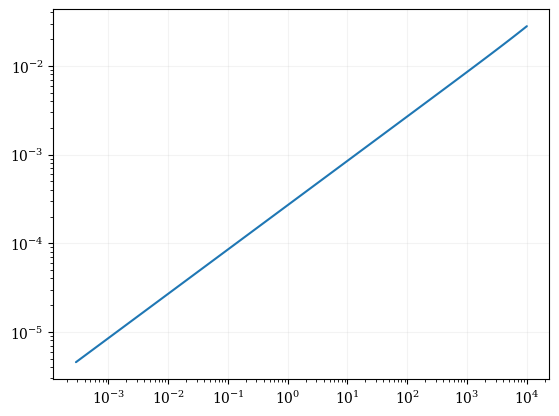

In [14]:
MTOT = 1e9 * MSOL
MRAT = 1.0
REDZ = 1.5
RMAX = 1.0e4 * PC

NPER_DEX = 2.3
# NPER_DEX = 1.0

print(f"{MTOT/MSOL=:.2e}, {MRAT=:.2f}, {REDZ=:.2f}, {RMAX/PC=:.2e}")

risco = utils.rad_isco(MTOT)
print(f"{risco/PC=:.2e}")

rads = np.logspace(*np.log10([RMAX, risco]), 101)
print(rads.size, rads/PC)

mmbulge = host_relations.MMBulge_KH2013()
mstar = mmbulge.mstar_from_mbh(MTOT, scatter=False)

smhm = host_relations.Guo_2010()
mhalo = smhm.halo_mass(mstar)
# smhm = holo.host_relations.Behroozi_2013()
# mhalo = smhm.halo_mass(mstar, REDZ)

print(f"{MTOT/MSOL=:.2e}, {mstar/MSOL=:.2e}, {mhalo/MSOL=:.2e}")

nfw = galaxy_profiles.NFW
times = nfw.time_dynamical(rads, mhalo, REDZ)

plt.loglog(rads/PC, times/GYR)

print(times.sum()/GYR)
